# Phase 2 - Data Understanding + Feature Audit

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Load data
train_txn = pd.read_csv(r'D:\fraud-detection-lab\data\train_transaction.csv')
train_id = pd.read_csv(r'D:\fraud-detection-lab\data\train_identity.csv')

# Merge
df = train_txn.merge(train_id, on='TransactionID', how='left')

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")

Shape: (590540, 434)
Fraud rate: 3.50%


In [10]:
# ============================================
# FEATURE AUDIT TABLE
# ============================================

def audit_feature(col, df, target='isFraud'):
    series = df[col]
    null_pct = series.isnull().mean() * 100
    unique_count = series.nunique()
    dtype = str(series.dtype)
    
    # Single feature AUC (numeric only)
    auc = np.nan
    if series.dtype in [np.float64, np.int64]:
        try:
            filled = series.fillna(-999)
            auc = roc_auc_score(df[target], filled)
            # Flip if AUC < 0.5 (feature predicts inverse)
            if auc < 0.5:
                auc = 1 - auc
        except:
            auc = np.nan
    
    return {
        'feature': col,
        'dtype': dtype,
        'null_pct': round(null_pct, 2),
        'unique_count': unique_count,
        'single_feature_auc': round(auc, 4) if not np.isnan(auc) else np.nan
    }

# Run audit on all features (takes 2-3 minutes)
print("Running feature audit... this takes ~2-3 minutes")

feature_cols = [c for c in df.columns if c not in ['isFraud', 'TransactionID']]
audit_results = [audit_feature(col, df) for col in feature_cols]
audit_df = pd.DataFrame(audit_results).sort_values('single_feature_auc', ascending=False)

print("Done!")
print(f"\nTotal features audited: {len(audit_df)}")
print(f"Numeric features: {(audit_df['dtype'] != 'object').sum()}")
print(f"Categorical features: {(audit_df['dtype'] == 'object').sum()}")
print(f"Features with >50% nulls: {(audit_df['null_pct'] > 50).sum()}")
print(f"Features with >90% nulls: {(audit_df['null_pct'] > 90).sum()}")

Running feature audit... this takes ~2-3 minutes
Done!

Total features audited: 432
Numeric features: 401
Categorical features: 31
Features with >50% nulls: 214
Features with >90% nulls: 12


In [11]:
# ============================================
# TOP 20 FEATURES BY SIGNAL
# ============================================

print("=== TOP 20 FEATURES (Highest Single-Feature AUC) ===")
print(audit_df[['feature', 'dtype', 'null_pct', 'unique_count', 'single_feature_auc']].head(20).to_string(index=False))

print("\n=== BOTTOM 10 FEATURES (Lowest Signal) ===")
print(audit_df[['feature', 'dtype', 'null_pct', 'unique_count', 'single_feature_auc']].dropna().tail(10).to_string(index=False))

print("\n=== FEATURES WITH >90% NULLS ===")
print(audit_df[audit_df['null_pct'] > 90][['feature', 'null_pct', 'single_feature_auc']].to_string(index=False))

=== TOP 20 FEATURES (Highest Single-Feature AUC) ===
feature   dtype  null_pct  unique_count  single_feature_auc
     C4 float64      0.00          1260              0.6877
     C8 float64      0.00          1253              0.6832
   V201 float64     76.32            56              0.6787
    C10 float64      0.00          1231              0.6779
   V199 float64     76.36            46              0.6776
   V200 float64     76.32            46              0.6772
   V168 float64     76.36           965              0.6766
   V171 float64     76.32            62              0.6764
   V204 float64     76.36         12858              0.6761
   V203 float64     76.36         14951              0.6759
   V170 float64     76.32            49              0.6756
   V190 float64     76.36            43              0.6753
   V167 float64     76.36           873              0.6751
   V178 float64     76.36          1236              0.6750
   V212 float64     76.36          8868        

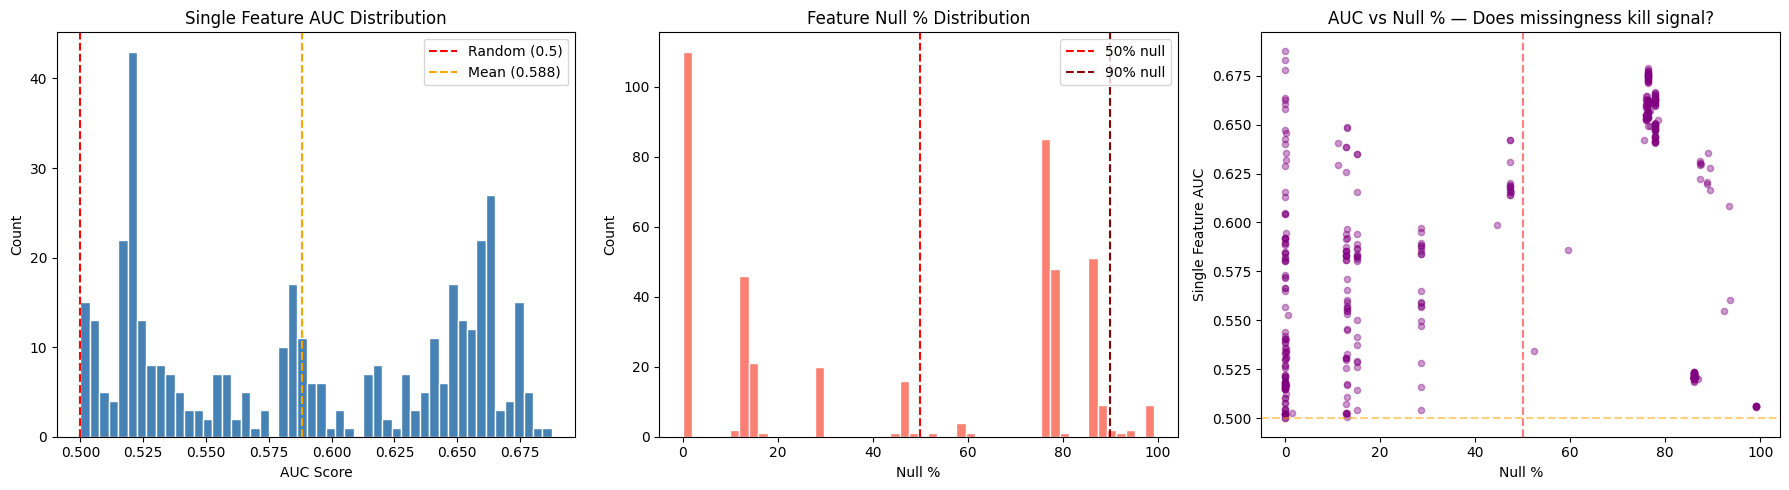

Plot saved to reports/


In [12]:
# ============================================
# FEATURE SIGNAL DISTRIBUTION
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: AUC distribution
auc_data = audit_df['single_feature_auc'].dropna()
axes[0].hist(auc_data, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Random (0.5)')
axes[0].axvline(x=auc_data.mean(), color='orange', linestyle='--', label=f'Mean ({auc_data.mean():.3f})')
axes[0].set_title('Single Feature AUC Distribution')
axes[0].set_xlabel('AUC Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Null % distribution
axes[1].hist(audit_df['null_pct'], bins=50, color='salmon', edgecolor='white')
axes[1].axvline(x=50, color='red', linestyle='--', label='50% null')
axes[1].axvline(x=90, color='darkred', linestyle='--', label='90% null')
axes[1].set_title('Feature Null % Distribution')
axes[1].set_xlabel('Null %')
axes[1].set_ylabel('Count')
axes[1].legend()

# Plot 3: AUC vs Null % scatter
axes[2].scatter(audit_df['null_pct'], audit_df['single_feature_auc'], 
                alpha=0.4, color='purple', s=20)
axes[2].axvline(x=50, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5)
axes[2].set_title('AUC vs Null % — Does missingness kill signal?')
axes[2].set_xlabel('Null %')
axes[2].set_ylabel('Single Feature AUC')

plt.tight_layout()
plt.savefig(r'D:\fraud-detection-lab\reports\feature_audit_plots.png', dpi=150)
plt.show()
print("Plot saved to reports/")

**Three clear insights from these plots:**
- **Plot 1 - AUC Distribution:**
Most features cluster around 0.50-0.53 (near random). But there's a strong right cluster at 0.65-0.68. Bimodal distribution - features are either useful or useless, not much in between. Mean of 0.588 is pulled up by that right cluster.

- **Plot 2 - Null Distribution:**
Three distinct groups - features with 0% nulls, features with ~47% nulls, and features with ~80% nulls. This isn't random missingness. Missingness is structured - likely different data collection systems or card types. This is important for feature engineering later.

- **Plot 3 - AUC vs Null % (most important):**
High null features (80%+) have some of the highest AUC scores (0.65-0.68). This destroys the assumption that "high null = drop it." Missingness itself is informative - whether a field is null or not might be a fraud signal.

In [14]:
# ============================================
# IS MISSINGNESS ITSELF A FRAUD SIGNAL?
# ============================================

# Test: for high-null features, does null/not-null separate fraud?
high_null_features = audit_df[
    (audit_df['null_pct'] > 50) & 
    (audit_df['single_feature_auc'] > 0.60)
]['feature'].tolist()

print(f"High-null (>50%) but high-signal (AUC>0.60) features: {len(high_null_features)}")
print()

results = []
for col in high_null_features[:10]:  # test top 10
    is_null = df[col].isnull().astype(int)
    fraud_when_null = df[df[col].isnull()]['isFraud'].mean()
    fraud_when_present = df[df[col].notna()]['isFraud'].mean()
    null_auc = roc_auc_score(df['isFraud'], is_null)
    
    results.append({
        'feature': col,
        'null_pct': round(df[col].isnull().mean()*100, 1),
        'fraud_rate_when_null': round(fraud_when_null*100, 2),
        'fraud_rate_when_present': round(fraud_when_present*100, 2),
        'null_indicator_auc': round(null_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values('null_indicator_auc', ascending=False)
print(results_df.to_string(index=False))
print()
print(f"Overall fraud rate: {df['isFraud'].mean()*100:.2f}%")
print()
print("→ Features where fraud_rate_when_null >> 3.50% mean nulls = fraud signal")

High-null (>50%) but high-signal (AUC>0.60) features: 132

feature  null_pct  fraud_rate_when_null  fraud_rate_when_present  null_indicator_auc
   V199      76.4                  2.13                     7.91              0.3457
   V168      76.4                  2.13                     7.91              0.3457
   V167      76.4                  2.13                     7.91              0.3457
   V204      76.4                  2.13                     7.91              0.3457
   V190      76.4                  2.13                     7.91              0.3457
   V203      76.4                  2.13                     7.91              0.3457
   V201      76.3                  2.13                     7.92              0.3451
   V200      76.3                  2.13                     7.92              0.3451
   V171      76.3                  2.13                     7.92              0.3451
   V170      76.3                  2.13                     7.92              0.3451

Overa

Fascinating. The signal is inverted from what you'd expect.

- Fraud rate when null: 2.13% (below baseline of 3.50%)
- Fraud rate when present: 7.91% (2.3x the baseline)

Being present is the fraud signal, not being null. These V-series features are only populated for certain transaction types — and those transaction types are disproportionately fraudulent. The missingness pattern tells you which data collection system processed the transaction, and that system correlates with fraud.
This means two things for feature engineering later:

1.Create is_present binary indicators for these features

2.Don't just fill nulls with -999 and forget - the null pattern is meaningful

In [24]:
# ============================================
# SAVE AUDIT TABLE + PHASE 2 SUMMARY
# ============================================

# Save full audit
audit_df.to_csv(r'D:\fraud-detection-lab\reports\feature_audit.csv', index=False)
print("Feature audit saved ✓")

# Segment features into buckets
high_signal   = audit_df[audit_df['single_feature_auc'] >= 0.62]['feature'].tolist()
medium_signal = audit_df[(audit_df['single_feature_auc'] >= 0.55) & 
                          (audit_df['single_feature_auc'] < 0.62)]['feature'].tolist()
low_signal    = audit_df[audit_df['single_feature_auc'] < 0.55]['feature'].tolist()
drop_candidates = audit_df[audit_df['null_pct'] > 90]['feature'].tolist()

print()
print("=== PHASE 2 FEATURE SUMMARY ===")
print(f"Total features:           {len(audit_df)}")
print(f"High signal  (AUC≥0.62): {len(high_signal)} features → priority for modeling")
print(f"Medium signal(AUC 0.55-0.62): {len(medium_signal)} features → include with caution")
print(f"Low signal   (AUC<0.55):  {len(low_signal)} features → likely noise")
print(f"Drop candidates (>90% null): {len(drop_candidates)} features")
print()
print("=== KEY INSIGHTS ===")
print("1. No feature has AUC > 0.70 — no leakage detected in raw features ✓")
print("2. 214 features have >50% nulls — but nulls ≠ no signal")
print("3. High-null V-series (76%): fraud rate 7.91% when present vs 2.13% when null")
print("   → Being present is the fraud signal, not being null")
print("4. Missingness is structured (0%, 47%, 80% clusters) — not random")
print("   → Different data collection systems, not data quality issues")
print("5. Bimodal AUC distribution — features are useful or useless, rarely middle ground")
print()
print("=== FEATURE ENGINEERING PRIORITIES (Phase 3) ===")
print("→ Create is_present indicators for high-null, high-signal V-series features")
print("→ Build transaction velocity features on C4, C8, C10 (top signal, 0% null)")
print("→ Drop id_22 through id_27 (99% null, AUC ~0.50 — pure noise)")
print()
print(f"High signal features: {high_signal[:10]} ...")

Feature audit saved ✓

=== PHASE 2 FEATURE SUMMARY ===
Total features:           432
High signal  (AUC≥0.62): 156 features → priority for modeling
Medium signal(AUC 0.55-0.62): 95 features → include with caution
Low signal   (AUC<0.55):  150 features → likely noise
Drop candidates (>90% null): 12 features

=== KEY INSIGHTS ===
1. No feature has AUC > 0.70 — no leakage detected in raw features ✓
2. 214 features have >50% nulls — but nulls ≠ no signal
3. High-null V-series (76%): fraud rate 7.91% when present vs 2.13% when null
   → Being present is the fraud signal, not being null
4. Missingness is structured (0%, 47%, 80% clusters) — not random
   → Different data collection systems, not data quality issues
5. Bimodal AUC distribution — features are useful or useless, rarely middle ground

=== FEATURE ENGINEERING PRIORITIES (Phase 3) ===
→ Create is_present indicators for high-null, high-signal V-series features
→ Build transaction velocity features on C4, C8, C10 (top signal, 0% null)